<a href="https://colab.research.google.com/github/Purva1204/DL_LAB_assignments/blob/main/Assignment-6/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub tensorflow matplotlib numpy

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

print("TensorFlow version:", tf.__version__)
print("KaggleHub version:", kagglehub.__version__)

TensorFlow version: 2.20.0
KaggleHub version: 1.0.2


In [ ]:
dataset_path = kagglehub.dataset_download(
    "mgmitesh/potato-disease-detection-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 37.8M/37.8M [00:00<00:00, 101MB/s] 

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/mgmitesh/potato-disease-detection-dataset/versions/1


In [ ]:
for root, dirs, files in os.walk(dataset_path):

    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print(root)
        print("Images:", len(image_files))

/root/.cache/kagglehub/datasets/mgmitesh/potato-disease-detection-dataset/versions/1/Potato___Late_blight
Images: 1000
/root/.cache/kagglehub/datasets/mgmitesh/potato-disease-detection-dataset/versions/1/Potato___healthy
Images: 152
/root/.cache/kagglehub/datasets/mgmitesh/potato-disease-detection-dataset/versions/1/Potato___Early_blight
Images: 1000


In [ ]:
class_folders = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

data_dir = None

for root, dirs, files in os.walk(dataset_path):

    if all(folder in dirs for folder in class_folders):
        data_dir = root
        break

print("Dataset directory:")
print(data_dir)

Dataset directory:
/root/.cache/kagglehub/datasets/mgmitesh/potato-disease-detection-dataset/versions/1


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123
EPOCHS = 20

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image size: (128, 128)
Batch size: 32
Epochs: 20


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 2152 files belonging to 3 classes.
Using 430 files for validation.


In [ ]:
class_names = train_ds.class_names

print("Classes:")

for i, name in enumerate(class_names):
    print(i, "→", name)

print("\nNumber of classes:", len(class_names))

Classes:
0 → Potato___Early_blight
1 → Potato___Late_blight
2 → Potato___healthy

Number of classes: 3


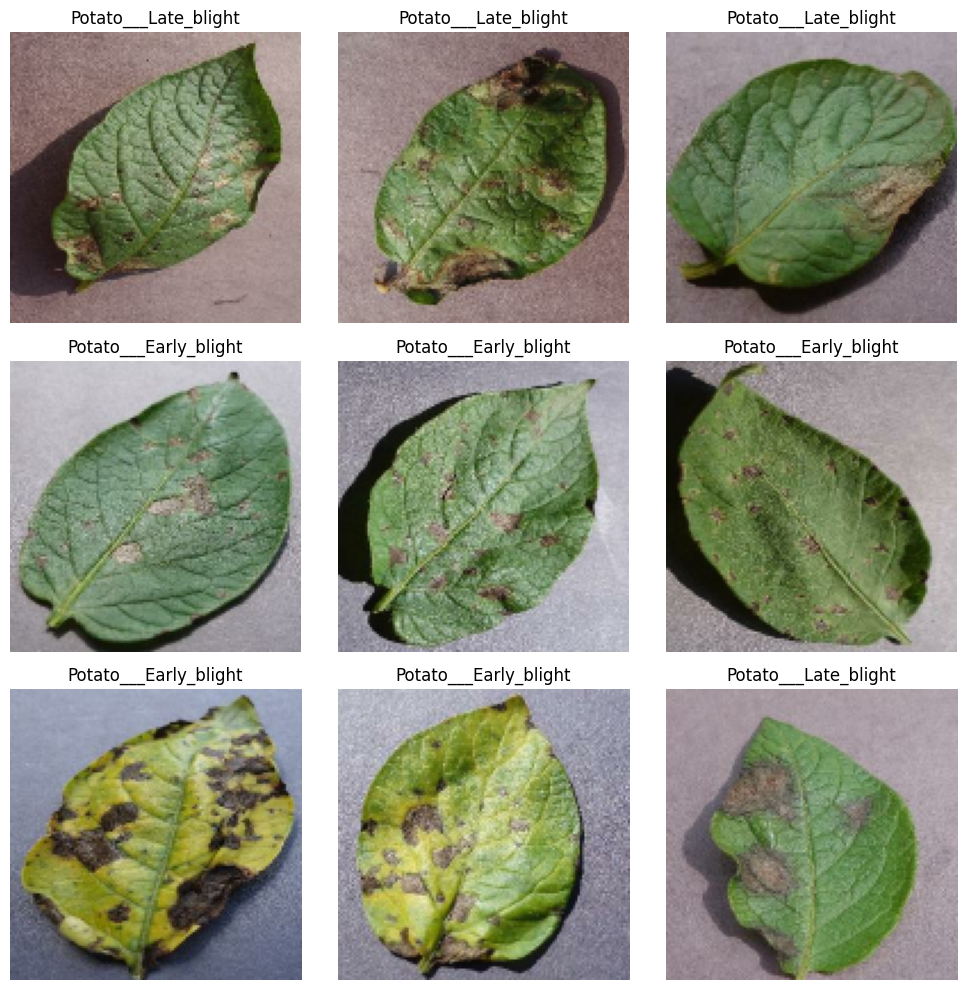

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("AUTOTUNE enabled successfully.")

AUTOTUNE enabled successfully.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation ready.")

Data augmentation ready.


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    data_augmentation,

    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

NameError: name 'model' is not defined

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.9721 - loss: 0.0750
Validation Loss: 0.07503282278776169
Validation Accuracy: 0.9720930457115173


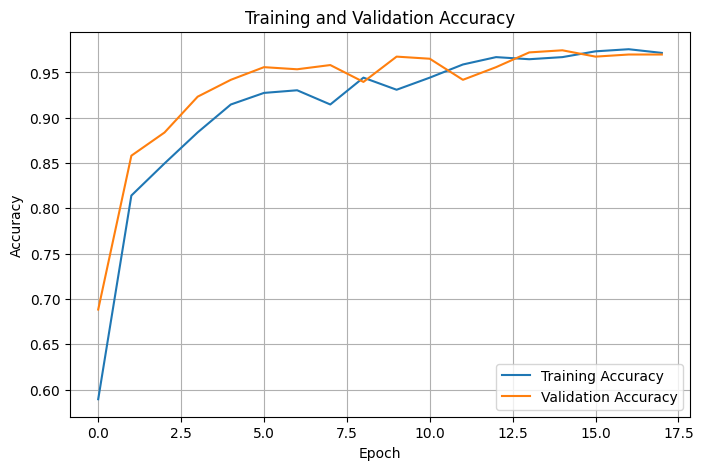

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

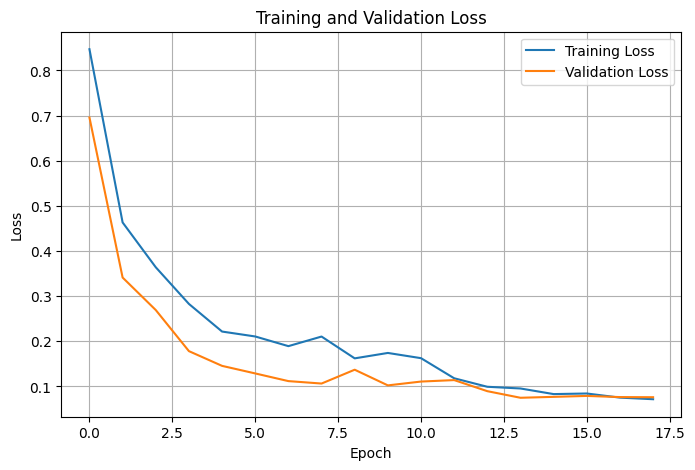

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving late-blight-potato-plant.jpg to late-blight-potato-plant.jpg


In [ ]:
image_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    axis=0
)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])

predicted_class = class_names[predicted_index]

confidence = predictions[0][predicted_index] * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class: Potato___Late_blight
Confidence: 69.77 %


In [ ]:
model.save("/content/potato_disease_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
